In [1]:
import pandas as pd, numpy as np, unicodedata, re
from rapidfuzz import process, fuzz
UP = "."   # ή ο φάκελος με τα csv (π.χ. "data" ή απόλυτο path)

# Παράθυρα κάθε μουντιάλ (έναρξη, λήξη)
TOURN = {
    "WC-2014": ("2014-06-12", "2014-07-13"),
    "WC-2018": ("2018-06-14", "2018-07-15"),
    "WC-2022": ("2022-11-20", "2022-12-18"),  # χειμωνιάτικο!
    "WC-2026": ("2026-06-11", "2026-07-19"),
}
TOURN = {k: (pd.Timestamp(a), pd.Timestamp(b)) for k, (a, b) in TOURN.items()}
TOP5 = {"GB1", "ES1", "IT1", "L1", "FR1"}   # κωδικοί top-5 πρωταθλημάτων (Transfermarkt)

# Κανονικοποίηση ονόματος: πεζά, χωρίς τόνους/σύμβολα -> για το matching
def norm(s):
    if pd.isna(s): return ""
    s = unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore").decode()
    s = re.sub(r"[^a-z ]", " ", s.lower())
    return re.sub(r"\s+", " ", s).strip()

# Κλειδί "πρώτο όνομα + τελευταίο επώνυμο" για matching παικτών
def fl_key(first, last):
    f, l = norm(first).split(), norm(last).split()
    return (f[0] + " " + l[-1]) if f and l else ""

# Παράδειγμα χρήσης των παραπάνω συναρτήσεων:                   
print(norm("Ángel Di María"))          # -> angel di maria
print(fl_key("Melvin Feycal", "MASTIL"))  # -> melvin mastil

angel di maria
melvin mastil


In [2]:
# ============== TRANSFERMARKT BRIDGE ==============
tm = pd.read_csv(f"{UP}/players_transf.csv")
tm["dob"]  = pd.to_datetime(tm.date_of_birth, errors="coerce").dt.normalize()
tm["full"] = tm.name.map(norm)
tm["flk"]  = [fl_key(a, b) for a, b in zip(tm.first_name, tm.last_name)]

# Λεξικά για γρήγορο matching ανά ημ. γέννησης (κλειδί = (όνομα, dob))
tm_by_full_dob = {}   # ακριβές: (full name, dob) -> tm_id
tm_by_flk_dob  = {}   # χαλαρό:  (first+last, dob) -> tm_id
tm_full_by_dob = {}   # dob -> [(full, id), ...]  για fuzzy μέσα στην ίδια dob
for r in tm.itertuples(index=False):
    if pd.notna(r.dob):
        tm_by_full_dob.setdefault((r.full, r.dob), r.player_id)
        tm_by_flk_dob.setdefault((r.flk, r.dob), r.player_id)
        tm_full_by_dob.setdefault(r.dob, []).append((r.full, r.player_id))

def resolve(full, flk, dob):
    """Επιστρέφει (tm_id, method) ή (None, None). Το dob είναι το 'άγκυρα' για ασφάλεια."""
    if pd.isna(dob):
        return (None, None)
    if (full, dob) in tm_by_full_dob:                       # 1) ακριβές όνομα + dob
        return (tm_by_full_dob[(full, dob)], "full+dob")
    if flk and (flk, dob) in tm_by_flk_dob:                 # 2) first+last + dob
        return (tm_by_flk_dob[(flk, dob)], "flk+dob")
    cands = tm_full_by_dob.get(dob)                          # 3) fuzzy στους ίδιας dob
    if cands and full:
        names = [c[0] for c in cands]
        hit = process.extractOne(full, names, scorer=fuzz.token_sort_ratio, score_cutoff=85)
        if hit:
            return (cands[hit[2]][1], "fuzzy+dob")
    return (None, None)

# γρήγορος έλεγχος: ο Μέσι (Lionel Messi, 1987-06-24) πρέπει να βρεθεί
print("rows transfermarkt:", len(tm))
print(resolve(norm("Lionel Messi"), fl_key("Lionel", "Messi"), pd.Timestamp("1987-06-24")))

rows transfermarkt: 47701
(28003, 'full+dob')


In [3]:
# ============== FJELSTUL PLAYERS + SQUADS ==============
players = pd.read_csv(f"{UP}/players.csv")
players["dob"] = pd.to_datetime(players.birth_date, errors="coerce").dt.normalize()

squads = pd.read_csv(f"{UP}/squads.csv")

# Μοναδικοί παίκτες που έπαιξαν στα 3 μουντιάλ-στόχους
wc_ids = squads[squads.tournament_id.isin(["WC-2014","WC-2018","WC-2022"])].player_id.unique()
pl = players[players.player_id.isin(wc_ids)].copy()
print("Fjelstul παίκτες 2014/18/22:", len(pl))

# Τρέχουμε τον resolve() για τον καθένα
res = []
for r in pl.itertuples(index=False):
    full = norm(f"{r.given_name} {r.family_name}")
    flk  = fl_key(r.given_name, r.family_name)
    tm_id, method = resolve(full, flk, r.dob)
    res.append((r.player_id, full, tm_id, method))

rdf = pd.DataFrame(res, columns=["fj_id","full","tm_id","method"])
matched = rdf.tm_id.notna().sum()
print(f"Ταίριασμα: {matched}/{len(rdf)} = {matched/len(rdf)*100:.1f}%")
print("\nΑνά μέθοδο:")
print(rdf.method.value_counts(dropna=False).to_string())

# Δείγμα από τους ΑΤΑΙΡΙΑΣΤΟΥΣ — να δούμε αν χάνουμε σημαντικούς παίκτες
print("\nΔείγμα αταίριαστων:")
print(rdf[rdf.tm_id.isna()].full.head(15).to_string())

Fjelstul παίκτες 2014/18/22: 1862
Ταίριασμα: 1506/1862 = 80.9%

Ανά μέθοδο:
method
full+dob     1414
NaN           356
fuzzy+dob      80
flk+dob        12

Δείγμα αταίριαστων:
2       mohamed abdel shafy
10         gabriel achilier
11            jhonny acosta
15            stephen adams
22           harrison afful
25           chigozie agbim
29             paul aguilar
32            rahman ahmadi
33              homam ahmed
40            daniel akpeyi
52         naif al hadhrami
53           salem al hajri
54         mansoor al harbi
57         taisir al jassim
59    abdulmalek al khaibri


In [4]:
# ============== ΚΟΜΜΑΤΙ 4: ΑΞΙΕΣ ==============
val = pd.read_csv(f"{UP}/player_valuations.csv", parse_dates=["date"]).sort_values("date")
val_grp = {pid: g for pid, g in val.groupby("player_id")}   # χρονοσειρά αξιών ανά παίκτη

def value_at(pid, ref, before=True, win_days=365):
    """before=True: τελευταία αξία <= ref (εντός win_days).
       before=False: πιο κοντινή στο ref+90 μέρες, αυστηρά μετά το ref."""
    if pd.isna(pid): return np.nan
    g = val_grp.get(int(pid))
    if g is None: return np.nan
    if before:
        m = g[(g.date <= ref) & (g.date >= ref - pd.Timedelta(days=win_days))]
        if m.empty: return np.nan
        return m.iloc[-1].market_value_in_eur
    else:
        m = g[(g.date > ref) & (g.date <= ref + pd.Timedelta(days=win_days))]
        if m.empty: return np.nan
        tgt = ref + pd.Timedelta(days=90)
        return m.iloc[(m.date - tgt).abs().values.argmin()].market_value_in_eur

# γρήγορος έλεγχος ξανά (Χάμες 2014)
s14, e14 = pd.Timestamp("2014-06-12"), pd.Timestamp("2014-07-13")
vb = value_at(88103, s14, before=True)
va = value_at(88103, e14, before=False)
print(f"Χάμες 2014: πριν={vb/1e6:.0f}M μετά={va/1e6:.0f}M -> {(va/vb-1)*100:+.0f}%") 

Χάμες 2014: πριν=35M μετά=60M -> +71%


In [5]:
# --- βοηθήματα: θέση παίκτη + επιδόσεις τουρνουά ---
pos_of = {}
for r in players.itertuples(index=False):
    pos_of[r.player_id] = ("GK" if r.goal_keeper else "DEF" if r.defender
                           else "MID" if r.midfielder else "FWD" if r.forward else "UNK")

goals = pd.read_csv(f"{UP}/goals.csv")
apps  = pd.read_csv(f"{UP}/player_appearances.csv")
g_cnt = goals[goals.own_goal == 0].groupby(["tournament_id", "player_id"]).size()
a_grp = apps.groupby(["tournament_id", "player_id"]).agg(
    matches=("match_id", "nunique"), starts=("starter", "sum"), subs=("substitute", "sum"))

def perf_feats(tid, pid):
    gl = int(g_cnt.get((tid, pid), 0))
    if (tid, pid) in a_grp.index:
        row = a_grp.loc[(tid, pid)]
        return gl, int(row.matches), int(row.starts), int(row.subs)
    return gl, 0, 0, 0

# --- ΝΕΟ: επαναχρησιμοποιούμε το matching του Κελιού 2 (rdf) αντί να ξανατρέχουμε resolve() ---
fj_to_tm = dict(zip(rdf.fj_id, rdf.tm_id))                  # fj_id -> tm_id (έτοιμο)
pl_idx   = players.drop_duplicates("player_id").set_index("player_id")  # O(1) lookup αντί για scan

# --- ο βρόχος για 2014/18/22 ---
rows = []
for tid in ["WC-2014", "WC-2018", "WC-2022"]:
    start, end = TOURN[tid]
    sub = squads[squads.tournament_id == tid].drop_duplicates("player_id")
    for r in sub.itertuples(index=False):
        if r.player_id not in pl_idx.index:
            continue
        prow = pl_idx.loc[r.player_id]
        gn, fn, dob = prow.given_name, prow.family_name, prow.dob
        tm_id = fj_to_tm.get(r.player_id)                  # αντί για resolve(...) ξανά
        gl, m, st, sb = perf_feats(tid, r.player_id)
        rows.append(dict(
            split="train", tournament=tid, player=norm(f"{gn} {fn}"),
            fj_id=r.player_id, tm_id=tm_id, dob=dob, team_id=r.team_id, team_name=r.team_name,
            position=pos_of.get(r.player_id, "UNK"),
            age=(start - dob).days / 365.25 if pd.notna(dob) else np.nan,
            value_before     = value_at(tm_id, start, before=True),
            value_before_12m = value_at(tm_id, start - pd.Timedelta(days=365), before=True),
            value_after      = value_at(tm_id, end, before=False),
            wc_goals=gl, wc_matches=m, wc_starts=st, wc_subs=sb,
        ))

train = pd.DataFrame(rows)
usable = train[(train.value_before > 0) & train.value_after.notna()]
print(f"Σύνολο γραμμές: {len(train)} | usable (έχουν before & after): {len(usable)}")
print(usable.groupby("tournament").size().to_string())


Σύνολο γραμμές: 2303 | usable (έχουν before & after): 1710
tournament
WC-2014    526
WC-2018    551
WC-2022    633


In [6]:
# ============== ΚΟΜΜΑΤΙ 6: ΓΡΑΜΜΕΣ 2026 (καθαρό) ==============
mu = pd.read_csv(f"{UP}/mundial_squads.csv")
mu["dob"] = pd.to_datetime(mu["DOB"], format="%d/%m/%Y", errors="coerce").dt.normalize()
mu = mu.rename(columns={"First Names": "first_names", "Last Names": "last_names"})
POSMAP = {"GK": "GK", "DF": "DEF", "MF": "MID", "FW": "FWD"}

s26, e26 = TOURN["WC-2026"]
rows26 = []
for r in mu.itertuples(index=False):
    full = norm(f"{r.first_names} {r.last_names}")
    tm_id, method = resolve(full, fl_key(r.first_names, r.last_names), r.dob)
    rows26.append(dict(
        split="predict", tournament="WC-2026", player=full,
        fj_id=None, tm_id=tm_id, dob=r.dob, team_id=None, team_name=r.Nationality,
        position=POSMAP.get(str(r.Position).strip(), "UNK"),
        age=(s26 - r.dob).days / 365.25 if pd.notna(r.dob) else np.nan,
        value_before     = value_at(tm_id, s26, before=True),
        value_before_12m = value_at(tm_id, s26 - pd.Timedelta(days=365), before=True),
        value_after      = np.nan,                  # δεν υπάρχει ακόμα
        wc_goals=np.nan, wc_matches=np.nan, wc_starts=np.nan, wc_subs=np.nan,
    ))

pred = pd.DataFrame(rows26)
print(f"2026: σύνολο {len(pred)} | matched {pred.tm_id.notna().sum()} | με value_before {(pred.value_before>0).sum()}")

2026: σύνολο 1248 | matched 780 | με value_before 384


In [7]:
# ============== ΚΟΜΜΑΤΙ 7: ΕΝΩΣΗ + TARGET + FEATURES ==============
# --- ΔΙΟΡΘΩΜΕΝΟ prior_wc μέσω tm_id (όχι μέσω ονόματος Fjelstul) ---
tr_tm = train.dropna(subset=["tm_id"]).copy()
tr_tm["year"] = tr_tm.tournament.str.split("-").str[1].astype(int)
tm_year = tr_tm.groupby("tm_id").year.apply(set).to_dict()   # tm_id -> έτη μουντιάλ που έπαιξε

def prior_wc_tm(tm_id, cur_year):
    if pd.isna(tm_id): return 0
    return sum(1 for y in tm_year.get(int(tm_id), set()) if y < cur_year)

train["prior_wc"] = [prior_wc_tm(t, int(tid.split("-")[1]))
                     for t, tid in zip(train.tm_id, train.tournament)]
pred["prior_wc"]  = [prior_wc_tm(t, 2026) for t in pred.tm_id]

# --- ένωση ---
df = pd.concat([train, pred], ignore_index=True)

# --- target (μόνο train έχει value_after) ---
ratio = df.value_after / df.value_before
ratio = ratio.where(ratio > 0)                     # μη-θετικοί λόγοι -> NaN (δεν μπαίνουν στο log)
df["target_logratio"] = np.log(ratio).replace([np.inf, -np.inf], np.nan)
df["target_pct"]      = (df.value_after / df.value_before - 1) * 100

# --- features ---
df["log_vb"]         = np.log(df.value_before)
df["value_trend_1y"] = np.log((df.value_before + 1) / (df.value_before_12m + 1)).fillna(0)
df["age"]            = df.age.fillna(df.age.median())
pos = pd.get_dummies(df.position, prefix="pos")     # GK/DEF/MID/FWD -> 0/1 στήλες
df = pd.concat([df, pos], axis=1)

df.to_csv("master.csv", index=False)

# --- έλεγχος ---
tr = df[(df.split=="train") & df.target_logratio.notna() & (df.value_before>0)]
print("train usable:", len(tr), "| 2026 με value_before:", ((df.split=="predict")&(df.value_before>0)).sum())
print(f"\ntarget_logratio: διάμεσος {tr.target_logratio.median():.3f} | μέση {tr.target_logratio.mean():.3f} | max {tr.target_logratio.max():.3f}")
print(f"prior_wc στο train -> 0:{(tr.prior_wc==0).sum()}  1:{(tr.prior_wc==1).sum()}  2+:{(tr.prior_wc>=2).sum()}")
print("\nΟι 5 μεγαλύτερες ανόδοι (sanity check):")
print(tr.nlargest(5,"target_logratio")[["player","tournament","target_pct"]]
      .assign(target_pct=lambda d: d.target_pct.round(0)).to_string(index=False))

train usable: 1710 | 2026 με value_before: 384

target_logratio: διάμεσος 0.000 | μέση 0.051 | max 2.526
prior_wc στο train -> 0:1339  1:305  2+:66

Οι 5 μεγαλύτερες ανόδοι (sanity check):
              player tournament  target_pct
     jefferson lerma    WC-2018      1150.0
        hamza mendyl    WC-2018       900.0
        divock origi    WC-2014       800.0
runar alex runarsson    WC-2018       800.0
          ali karimi    WC-2022       550.0


In [8]:
# ============== ΚΟΜΜΑΤΙ 8: SPLIT + ΑΞΙΟΛΟΓΗΣΗ ==============
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import spearmanr

POS_COLS = [c for c in df.columns if c.startswith("pos_")]
FEATS = ["age", "log_vb", "value_trend_1y", "prior_wc"] + POS_COLS   # pre-tournament (το τίμιο set για 2026)
RISER = 0.40   # κατώφλι "μεγάλης ανόδου" (~ +49%)

tr = df[(df.split=="train") & df.target_logratio.notna() & (df.value_before>0)].copy()

def evaluate(y_true, y_pred, k=20):
    idx = np.argsort(y_pred)[::-1][:k]   # top-k κατά πρόβλεψη
    return dict(
        MAE=mean_absolute_error(y_true, y_pred),
        RMSE=np.sqrt(mean_squared_error(y_true, y_pred)),
        R2=r2_score(y_true, y_pred),
        Spearman=spearmanr(y_true, y_pred).statistic,   # πόσο καλά κατατάσσει
        **{f"P@{k}": (np.asarray(y_true)[idx] >= RISER).mean()})  # πόσοι top-k ήταν όντως ανερχόμενοι

# Temporal split: μάθε σε 2014+2018, τεστ στο 2022 (= "προβλέπω το επόμενο μουντιάλ")
te = tr[tr.tournament=="WC-2022"]
trn = tr[tr.tournament.isin(["WC-2014","WC-2018"])]
Xtr, ytr = trn[FEATS].astype(float).values, trn.target_logratio.values
Xte, yte = te[FEATS].astype(float).values, te.target_logratio.values
sc = StandardScaler().fit(Xtr); Xtr_s, Xte_s = sc.transform(Xtr), sc.transform(Xte)

res = {
    "Dummy (mean)": evaluate(yte, np.full_like(yte, ytr.mean())),
    "Ridge":        evaluate(yte, Ridge(alpha=1.0).fit(Xtr_s, ytr).predict(Xte_s)),
}
print(f"train: {len(trn)} (2014+18) | test: {len(te)} (2022)\n")
print(pd.DataFrame(res).T[["MAE","RMSE","R2","Spearman","P@20"]].round(3).to_string())

train: 1077 (2014+18) | test: 633 (2022)

                MAE   RMSE     R2  Spearman  P@20
Dummy (mean)  0.230  0.309 -0.033       NaN   0.1
Ridge         0.208  0.281  0.147     0.485   0.4


C:\Users\User\AppData\Local\Temp\ipykernel_47924\4018760564.py:20: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  Spearman=spearmanr(y_true, y_pred).statistic,   # πόσο καλά κατατάσσει


In [9]:
# ============== ΚΟΜΜΑΤΙ 9: BASELINES ΜΕ ΔΕΝΤΡΑ ==============
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

res["RandomForest"] = evaluate(yte, RandomForestRegressor(
    n_estimators=300, max_depth=8, random_state=42, n_jobs=-1).fit(Xtr, ytr).predict(Xte))

res["GradientBoosting"] = evaluate(yte, GradientBoostingRegressor(
    n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42).fit(Xtr, ytr).predict(Xte))

print(pd.DataFrame(res).T[["MAE","RMSE","R2","Spearman","P@20"]].round(3).to_string())

                    MAE   RMSE     R2  Spearman  P@20
Dummy (mean)      0.230  0.309 -0.033       NaN  0.10
Ridge             0.208  0.281  0.147     0.485  0.40
RandomForest      0.215  0.300  0.031     0.488  0.40
GradientBoosting  0.225  0.320 -0.107     0.478  0.35


In [10]:
# ============== ΚΟΜΜΑΤΙ 10: KERAS MLP ==============
import os; os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
import tensorflow as tf
import keras
tf.random.set_seed(42); np.random.seed(42)

def make_mlp(n_features):
    m = keras.Sequential([
        keras.layers.Input(shape=(n_features,)),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(1)])               # regression -> 1 έξοδος, χωρίς activation
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
    return m

mlp = make_mlp(Xtr_s.shape[1])
mlp.fit(Xtr_s, ytr, validation_split=0.15, epochs=200, batch_size=32, verbose=0,
        callbacks=[keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True)])

res["Keras MLP"] = evaluate(yte, mlp.predict(Xte_s, verbose=0).ravel())
print(pd.DataFrame(res).T[["MAE","RMSE","R2","Spearman","P@20"]].round(3).to_string())

                    MAE   RMSE     R2  Spearman  P@20
Dummy (mean)      0.230  0.309 -0.033       NaN  0.10
Ridge             0.208  0.281  0.147     0.485  0.40
RandomForest      0.215  0.300  0.031     0.488  0.40
GradientBoosting  0.225  0.320 -0.107     0.478  0.35
Keras MLP         0.198  0.280  0.153     0.480  0.35


In [11]:
# ============== ΚΟΜΜΑΤΙ 11: ΠΡΟΒΛΕΨΕΙΣ 2026 ==============
# refit σε ΟΛΟ το train (2014+18+22)
Xall = tr[FEATS].astype(float).values
yall = tr.target_logratio.values
sc_all = StandardScaler().fit(Xall)

mlp_f = make_mlp(Xall.shape[1])
mlp_f.fit(sc_all.transform(Xall), yall, validation_split=0.15, epochs=200, batch_size=32,
          verbose=0, callbacks=[keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True)])
ridge_f = Ridge(alpha=1.0).fit(sc_all.transform(Xall), yall)

# πρόβλεψη στους 384 του 2026
P = df[(df.split=="predict") & (df.value_before>0)].copy()
Xp = sc_all.transform(P[FEATS].astype(float).values)
P["pred_logratio"] = (mlp_f.predict(Xp, verbose=0).ravel() + ridge_f.predict(Xp)) / 2
P["pred_pct"] = (np.exp(P["pred_logratio"]) - 1) * 100

P.sort_values("pred_logratio", ascending=False).to_csv("predictions_2026.csv", index=False)

def show(d, n):
    v = d.head(n).copy()
    v["value_before"] = (v.value_before/1e6).round(1); v["age"]=v.age.round(1); v["pred_pct"]=v.pred_pct.round(0)
    return v[["player","team_name","position","age","value_before","prior_wc","pred_pct"]].to_string(index=False)

P = P.sort_values("pred_logratio", ascending=False)
print("=== TOP-20 ΑΝΕΡΧΟΜΕΝΟΙ (όλοι) ===")
print(show(P, 20))
print("\n=== TOP-15 ΓΝΩΣΤΑ ΟΝΟΜΑΤΑ (αξία πριν ≥ 10M) ===")
print(show(P[P.value_before >= 10e6], 15))

=== TOP-20 ΑΝΕΡΧΟΜΕΝΟΙ (όλοι) ===
                           player              team_name position  age  value_before  prior_wc  pred_pct
                samir el mourabet                Morocco      MID 20.7           8.0         0      83.0
                      nidal celik Bosnia And Herzegovina      DEF 19.9           1.0         0      54.0
               tyler grant bindon            New Zealand      DEF 21.4           1.5         0      52.0
                     yan diomande          Côte D'Ivoire      FWD 19.6          45.0         0      50.0
                    ibrahim mbaye                Senegal      FWD 18.4          25.0         0      41.0
                    kento shiogai                  Japan      FWD 21.2           2.5         0      40.0
   robin francois philippe risser                 France       GK 21.5          10.0         0      40.0
                  mohamed a toure              Australia      FWD 22.2           1.7         0      37.0
              antoine

Permutation importance (MLP, αύξηση MAE):
age               0.0365
value_trend_1y    0.0130
log_vb            0.0123
pos_MID           0.0020
pos_GK            0.0013
pos_FWD          -0.0002
pos_DEF          -0.0002
prior_wc         -0.0006


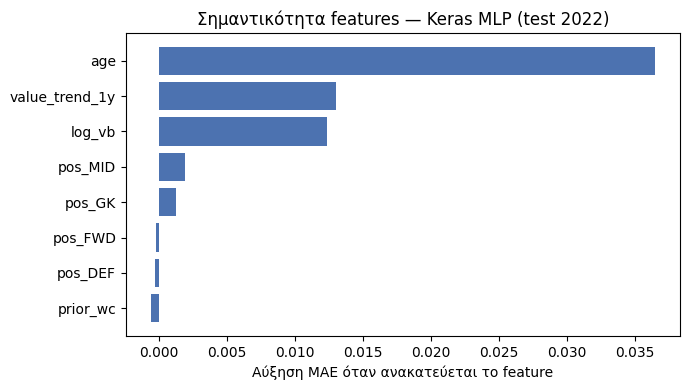

In [12]:
# ============== ΚΟΜΜΑΤΙ 12: PERMUTATION FEATURE IMPORTANCE ==============
import matplotlib.pyplot as plt

def perm_importance(predict_fn, X, y, feat_names, n_repeats=10, seed=42):
    rng = np.random.default_rng(seed)
    base = mean_absolute_error(y, predict_fn(X))      # σφάλμα με όλα τα features
    out = {}
    for j, name in enumerate(feat_names):
        scores = []
        for _ in range(n_repeats):
            Xp = X.copy(); rng.shuffle(Xp[:, j])      # κατέστρεψε ΜΟΝΟ αυτό το feature
            scores.append(mean_absolute_error(y, predict_fn(Xp)))
        out[name] = np.mean(scores) - base            # πόσο αυξήθηκε το σφάλμα = σημαντικότητα
    return pd.Series(out).sort_values()

mlp_predict = lambda X: mlp.predict(X, verbose=0).ravel()
imp = perm_importance(mlp_predict, Xte_s, yte, FEATS, n_repeats=15)

print("Permutation importance (MLP, αύξηση MAE):")
print(imp.sort_values(ascending=False).round(4).to_string())

plt.figure(figsize=(7, 4))
plt.barh(imp.index, imp.values, color="#4C72B0")
plt.xlabel("Αύξηση MAE όταν ανακατεύεται το feature")
plt.title("Σημαντικότητα features — Keras MLP (test 2022)")
plt.tight_layout(); plt.savefig("feature_importance.png", dpi=130); plt.show()

In [13]:
# ============== ΚΟΜΜΑΤΙ 13: ΣΤΟΧΟΣ Β (absolute Δ€) ==============
# Δ σε εκατ. € (δουλεύουμε σε εκατομμύρια για αριθμητική άνεση)
df["target_abs_m"] = (df.value_after - df.value_before) / 1e6

# signed-log: συμπιέζει τα ακραία ΚΑΙ κρατάει το πρόσημο (37% έχασαν αξία!)
def slog(x):  return np.sign(x) * np.log1p(np.abs(x))
def slog_inv(y): return np.sign(y) * np.expm1(np.abs(y))   # αντίστροφο, για να γυρίσουμε σε €

df["target_B"] = slog(df["target_abs_m"])

# έλεγχος στο train
trB = df[(df.split=="train") & df.target_B.notna() & (df.value_before>0)].copy()
print(f"train usable (Β): {len(trB)}")
print(f"λοξότητα: σκέτο Δ€ {trB.target_abs_m.skew():.2f} -> signed-log {trB.target_B.skew():.2f}")
print(f"εύρος target_B: [{trB.target_B.min():.2f}, {trB.target_B.max():.2f}]")
# επαλήθευση ότι το αντίστροφο δουλεύει
print("sanity inv:", round(slog_inv(slog(60.0)), 1), "== 60.0 ?")

train usable (Β): 1710
λοξότητα: σκέτο Δ€ 3.41 -> signed-log 0.29
εύρος target_B: [-3.04, 4.11]
sanity inv: 60.0 == 60.0 ?


In [14]:
# ============== ΚΟΜΜΑΤΙ 14: HARNESS ΓΙΑ ΣΤΟΧΟ Β ==============
RISER_B = slog(10.0)   # "μεγάλη άνοδος" = κέρδισε >=10M €, στην signed-log κλίμακα

def evaluate_B(y_true, y_pred, k=20):
    idx = np.argsort(y_pred)[::-1][:k]
    return dict(
        MAE=mean_absolute_error(y_true, y_pred),
        RMSE=np.sqrt(mean_squared_error(y_true, y_pred)),
        R2=r2_score(y_true, y_pred),
        Spearman=spearmanr(y_true, y_pred).statistic if np.ptp(y_pred) > 0 else np.nan,
        **{f"P@{k}": (np.asarray(y_true)[idx] >= RISER_B).mean()})

# split στον ίδιο διαχωρισμό, νέα στήλη-στόχος
teB  = trB[trB.tournament == "WC-2022"]
trnB = trB[trB.tournament.isin(["WC-2014","WC-2018"])]
XtrB, ytrB = trnB[FEATS].astype(float).values, trnB.target_B.values
XteB, yteB = teB[FEATS].astype(float).values,  teB.target_B.values
scB = StandardScaler().fit(XtrB); XtrB_s, XteB_s = scB.transform(XtrB), scB.transform(XteB)

resB = {}
resB["Dummy (mean)"]     = evaluate_B(yteB, np.full_like(yteB, ytrB.mean()))
resB["Ridge"]            = evaluate_B(yteB, Ridge(alpha=1.0).fit(XtrB_s, ytrB).predict(XteB_s))
resB["RandomForest"]     = evaluate_B(yteB, RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1).fit(XtrB, ytrB).predict(XteB))
resB["GradientBoosting"] = evaluate_B(yteB, GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=42).fit(XtrB, ytrB).predict(XteB))

mlpB = make_mlp(XtrB_s.shape[1])
mlpB.fit(XtrB_s, ytrB, validation_split=0.15, epochs=200, batch_size=32, verbose=0,
         callbacks=[keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True)])
resB["Keras MLP"] = evaluate_B(yteB, mlpB.predict(XteB_s, verbose=0).ravel())

print("=== ΣΤΟΧΟΣ Β (absolute Δ€, signed-log) — test 2022 ===")
print(pd.DataFrame(resB).T[["MAE","RMSE","R2","Spearman","P@20"]].round(3).to_string())
print("\n--- για σύγκριση, ΣΤΟΧΟΣ Α ---")
print(pd.DataFrame(res).T[["MAE","RMSE","R2","Spearman","P@20"]].round(3).to_string())

=== ΣΤΟΧΟΣ Β (absolute Δ€, signed-log) — test 2022 ===
                    MAE   RMSE     R2  Spearman  P@20
Dummy (mean)      1.017  1.294 -0.011       NaN  0.05
Ridge             0.910  1.167  0.178     0.450  0.35
RandomForest      0.852  1.146  0.208     0.465  0.40
GradientBoosting  0.857  1.150  0.202     0.462  0.35
Keras MLP         0.867  1.147  0.207     0.483  0.40

--- για σύγκριση, ΣΤΟΧΟΣ Α ---
                    MAE   RMSE     R2  Spearman  P@20
Dummy (mean)      0.230  0.309 -0.033       NaN  0.10
Ridge             0.208  0.281  0.147     0.485  0.40
RandomForest      0.215  0.300  0.031     0.488  0.40
GradientBoosting  0.225  0.320 -0.107     0.478  0.35
Keras MLP         0.198  0.280  0.153     0.480  0.35


In [15]:
# ============== ΚΟΜΜΑΤΙ 15: ΛΙΣΤΑ 2026 — ΣΤΟΧΟΣ Β ==============
XallB = trB[FEATS].astype(float).values
yallB = trB.target_B.values
scB_all = StandardScaler().fit(XallB)

mlpB_f = make_mlp(XallB.shape[1])
mlpB_f.fit(scB_all.transform(XallB), yallB, validation_split=0.15, epochs=200, batch_size=32,
           verbose=0, callbacks=[keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True)])

PB = df[(df.split=="predict") & (df.value_before>0)].copy()
XpB = scB_all.transform(PB[FEATS].astype(float).values)
PB["pred_B_slog"] = mlpB_f.predict(XpB, verbose=0).ravel()
PB["pred_gain_m"] = slog_inv(PB["pred_B_slog"])          # γύρνα σε εκατ. €
PB = PB.sort_values("pred_gain_m", ascending=False)
PB.to_csv("predictions_2026_targetB.csv", index=False)

def showB(d, n):
    v = d.head(n).copy()
    v["value_before"]=(v.value_before/1e6).round(1); v["age"]=v.age.round(1); v["pred_gain_m"]=v.pred_gain_m.round(1)
    return v[["player","team_name","position","age","value_before","pred_gain_m"]].to_string(index=False)

print("=== TOP-20 — ΑΠΟΛΥΤΟ ΚΕΡΔΟΣ ΑΞΙΑΣ 2026 (εκατ. €) ===")
print(showB(PB, 20))
print(f"\nΜέση ηλικία top-20 (Β): {PB.head(20).age.mean():.1f}  |  vs αντίστοιχη του Α ήταν ~20.5")

=== TOP-20 — ΑΠΟΛΥΤΟ ΚΕΡΔΟΣ ΑΞΙΑΣ 2026 (εκατ. €) ===
                        player     team_name position  age  value_before  pred_gain_m
             samir el mourabet       Morocco      MID 20.7           8.0          3.5
                  yan diomande Côte D'Ivoire      FWD 19.6          45.0          3.4
                 luka vuskovic       Croatia      DEF 19.3          40.0          3.0
                 ibrahim mbaye       Senegal      FWD 18.4          25.0          2.6
           johan kula manzambi   Switzerland      MID 20.7          30.0          2.3
                 nico o reilly       England      DEF 21.2          40.0          2.1
                ayyoub bouaddi       Morocco      MID 18.7          40.0          2.1
                  lennart karl       Germany      MID 18.3          60.0          1.9
              zeno koen debast       Belgium      DEF 22.6          30.0          1.8
               chemsdine talbi       Morocco      MID 21.1          22.0          1.8
 